In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# Define the paths
ROOT = Path("/beegfs/halder/GITHUB/RESEARCH/WBCrop")
pts_path = ROOT / "data" / "processed" / "wbcrop_points.gpkg"
fields_path = ROOT / "data" / "processed" / "wbcrop_fields.gpkg"
wb_path = ROOT / "data" / "raw" / "shapefile" / "west_bengal.gpkg"

# ── load data ────────────────────────────────────────────────────────────
pts = gpd.read_file(pts_path)
fields = gpd.read_file(fields_path)
wb = gpd.read_file(wb_path)

# Ensure everything is in WGS 84 for the spatial map
pts_wgs = pts.to_crs(epsg=4326)
fields_wgs = fields.to_crs(epsg=4326)
wb_wgs = wb.to_crs(epsg=4326)

print(f"Points : {len(pts_wgs):,}  |  Fields : {len(fields_wgs):,}")
print(f"Crop classes (points) : {sorted(pts_wgs['crop'].unique())}")
print(f"Crop classes (fields) : {sorted(fields_wgs['crop'].unique())}")

Points : 45,616  |  Fields : 42,476
Crop classes (points) : ['aman_rice', 'aus_rice', 'banana', 'betel_leaf', 'boro_rice', 'flower', 'groundnut', 'jute', 'maize', 'mustard', 'others', 'pine_apple', 'potato', 'sugarcane', 'tea', 'tobacco', 'vegetables', 'wheat']
Crop classes (fields) : ['aman_rice', 'aus_rice', 'banana', 'betel_leaf', 'boro_rice', 'flower', 'groundnut', 'jute', 'maize', 'mustard', 'others', 'pine_apple', 'potato', 'sugarcane', 'tea', 'tobacco', 'vegetables', 'wheat']


## Figure 1 — Spatial Distribution of Crop Samples & Fields across West Bengal


/tmp/ipykernel_261374/3769188707.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)
/tmp/ipykernel_261374/3769188707.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


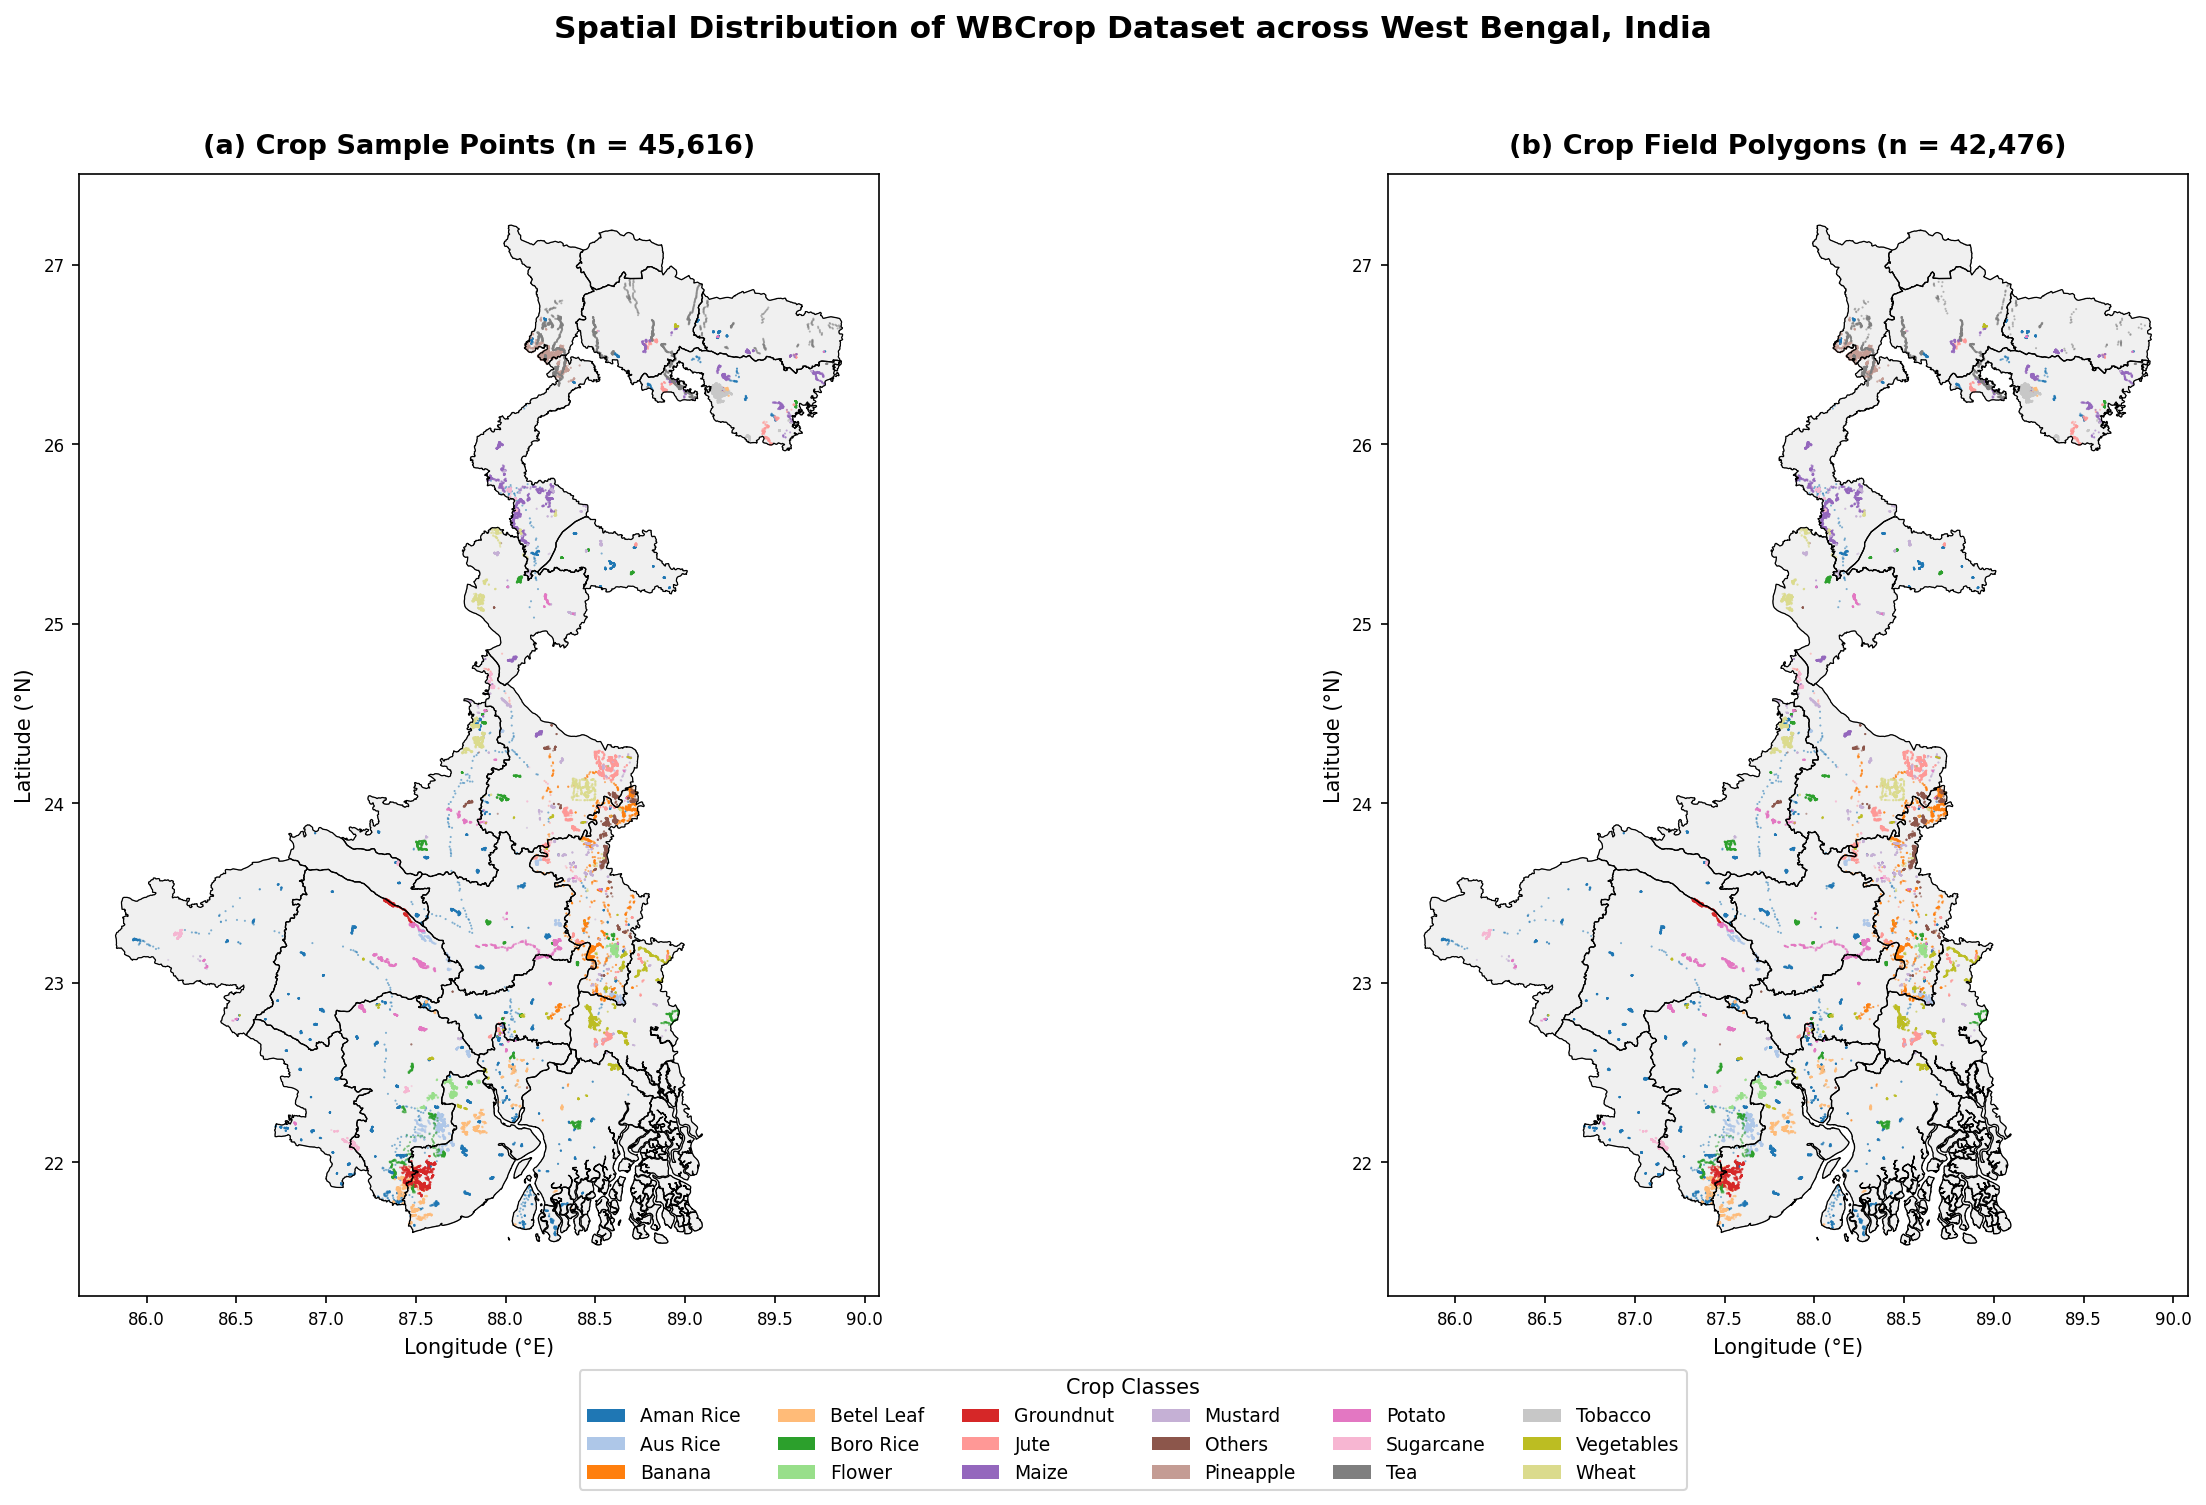

✓ Figure 1 saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Spatial Distribution Map  (side-by-side: Points | Fields)
# ══════════════════════════════════════════════════════════════════════════

# ── pretty crop label map ────────────────────────────────────────────────
LABEL_MAP = {
    "aman_rice": "Aman Rice",
    "aus_rice": "Aus Rice",
    "banana": "Banana",
    "betel_leaf": "Betel Leaf",
    "boro_rice": "Boro Rice",
    "flower": "Flower",
    "groundnut": "Groundnut",
    "jute": "Jute",
    "maize": "Maize",
    "mustard": "Mustard",
    "others": "Others",
    "pine_apple": "Pineapple",
    "potato": "Potato",
    "sugarcane": "Sugarcane",
    "tea": "Tea",
    "tobacco": "Tobacco",
    "vegetables": "Vegetables",
    "wheat": "Wheat",
}

# ── 18-class qualitative palette (tab20 minus 2 duplicates) ─────────────
cmap = plt.cm.get_cmap("tab20", 20)
CROP_ORDER = sorted(LABEL_MAP.keys())
COLOR_MAP = {c: cmap(i) for i, c in enumerate(CROP_ORDER)}

pts_wgs["color"] = pts_wgs["crop"].map(COLOR_MAP)
fields_wgs["color"] = fields_wgs["crop"].map(COLOR_MAP)

# ── figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10), dpi=150)

for ax, gdf, title, geom_type in zip(
    axes,
    [pts_wgs, fields_wgs],
    [
        f"(a) Crop Sample Points (n = {len(pts_wgs):,})",
        f"(b) Crop Field Polygons (n = {len(fields_wgs):,})",
    ],
    ["points", "fields"],
):
    # West Bengal boundary
    wb_wgs.boundary.plot(ax=ax, color="black", linewidth=0.6)
    wb_wgs.plot(ax=ax, color="#f0f0f0", edgecolor="grey", linewidth=0.3)

    # Plot crop samples
    if geom_type == "points":
        ax.scatter(
            gdf.geometry.x,
            gdf.geometry.y,
            c=gdf["color"],
            s=1.0,
            alpha=0.55,
            linewidths=0,
            rasterized=True,
        )
    else:
        # For fields, use centroids for clarity at this scale
        centroids = gdf.geometry.centroid
        ax.scatter(
            centroids.x,
            centroids.y,
            c=gdf["color"],
            s=1.0,
            alpha=0.55,
            linewidths=0,
            rasterized=True,
        )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°N)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_aspect("equal")

# ── shared legend ────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=COLOR_MAP[c], label=LABEL_MAP[c]) for c in CROP_ORDER
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=6,
    fontsize=9,
    frameon=True,
    fancybox=True,
    title="Crop Classes",
    title_fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Spatial Distribution of WBCrop Dataset across West Bengal, India",
    fontsize=15,
    fontweight="bold",
    y=0.97,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.savefig(
    ROOT / "notebooks" / "00_exploration" / "fig1_spatial_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print("✓ Figure 1 saved.")

## Figure 2 — Class Distribution (18 Crop Classes) for Points & Fields


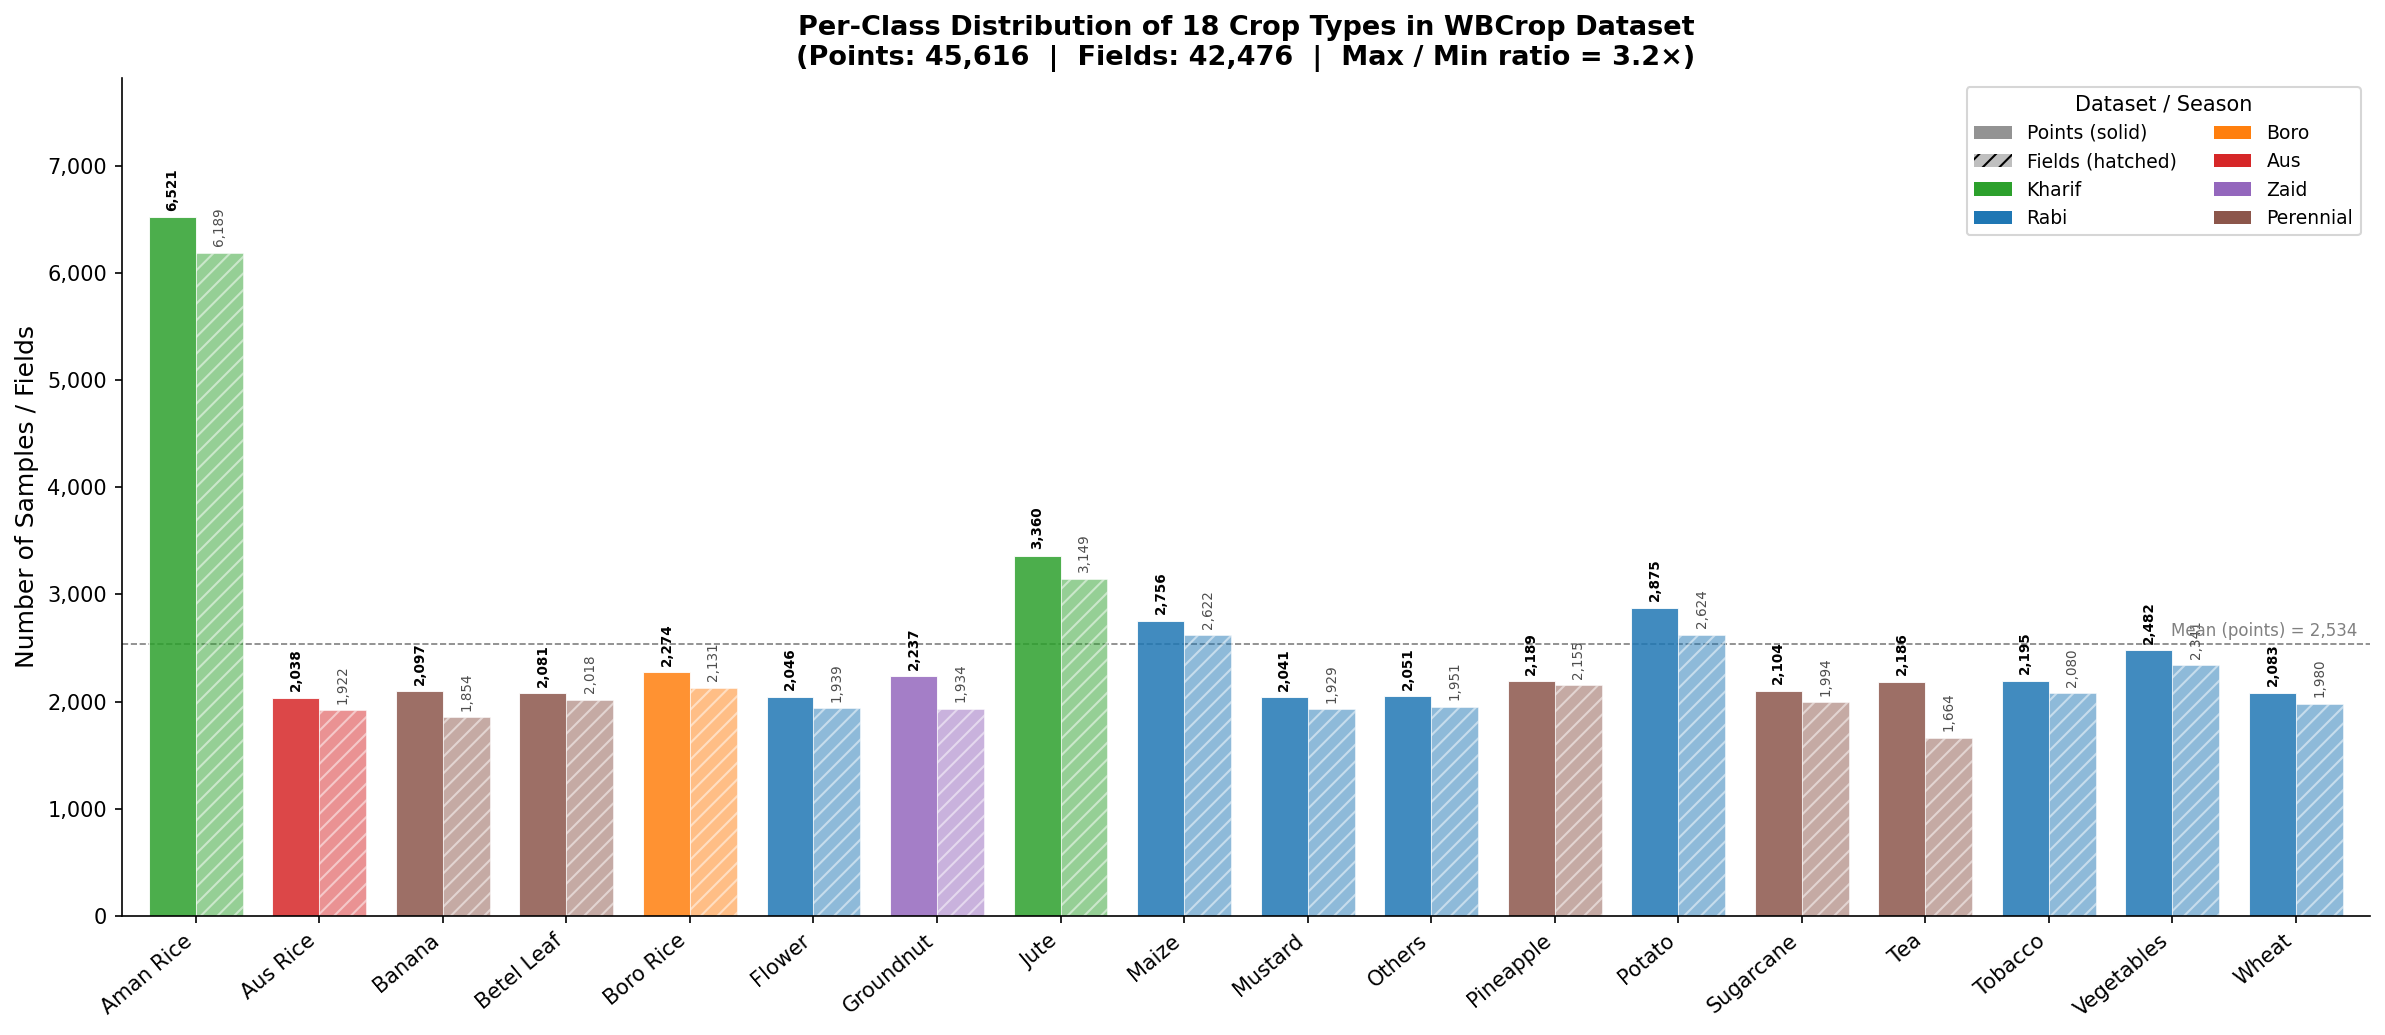

✓ Figure 2 saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Class Imbalance Bar Chart  (grouped bars: Points vs Fields)
# ══════════════════════════════════════════════════════════════════════════

# ── season colour map (for bar colouring) ────────────────────────────────
SEASON_MAP = {
    "aman_rice": "Kharif",
    "aus_rice": "Aus",
    "banana": "Perennial",
    "betel_leaf": "Perennial",
    "boro_rice": "Boro",
    "flower": "Rabi",
    "groundnut": "Zaid",
    "jute": "Kharif",
    "maize": "Rabi",
    "mustard": "Rabi",
    "others": "Rabi",
    "pine_apple": "Perennial",
    "potato": "Rabi",
    "sugarcane": "Perennial",
    "tea": "Perennial",
    "tobacco": "Rabi",
    "vegetables": "Rabi",
    "wheat": "Rabi",
}

SEASON_COLORS = {
    "Kharif": "#2ca02c",
    "Rabi": "#1f77b4",
    "Boro": "#ff7f0e",
    "Aus": "#d62728",
    "Zaid": "#9467bd",
    "Perennial": "#8c564b",
}

# ── counts ───────────────────────────────────────────────────────────────
pts_counts = pts_wgs["crop"].value_counts().reindex(CROP_ORDER)
fields_counts = fields_wgs["crop"].value_counts().reindex(CROP_ORDER)

labels = [LABEL_MAP[c] for c in CROP_ORDER]
seasons = [SEASON_MAP[c] for c in CROP_ORDER]
bar_colors = [SEASON_COLORS[s] for s in seasons]

x = np.arange(len(CROP_ORDER))
bar_w = 0.38

# ── figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

bars1 = ax.bar(
    x - bar_w / 2,
    pts_counts.values,
    bar_w,
    label="Points",
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
bars2 = ax.bar(
    x + bar_w / 2,
    fields_counts.values,
    bar_w,
    label="Fields",
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.50,
    hatch="///",
)

# ── count labels above bars ──────────────────────────────────────────────
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=6.5,
        fontweight="bold",
        rotation=90,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=6.5,
        rotation=90,
        color="0.3",
    )

# ── imbalance ratio line ─────────────────────────────────────────────────
ratio = pts_counts.max() / pts_counts.min()
ax.axhline(pts_counts.mean(), color="grey", ls="--", lw=0.8, zorder=0)
ax.text(
    len(CROP_ORDER) - 0.5,
    pts_counts.mean() + 80,
    f"Mean (points) = {pts_counts.mean():,.0f}",
    fontsize=8,
    color="grey",
    ha="right",
)

# ── axes formatting ──────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Number of Samples / Fields", fontsize=12)
ax.set_title(
    "Per-Class Distribution of 18 Crop Types in WBCrop Dataset\n"
    f"(Points: {len(pts_wgs):,}  |  Fields: {len(fields_wgs):,}  |  "
    f"Max / Min ratio = {ratio:.1f}×)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlim(-0.6, len(CROP_ORDER) - 0.4)
ax.set_ylim(0, pts_counts.max() * 1.20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# ── legend: dataset type + season ────────────────────────────────────────
from matplotlib.lines import Line2D

dataset_handles = [
    mpatches.Patch(facecolor="grey", alpha=0.85, label="Points (solid)"),
    mpatches.Patch(facecolor="grey", alpha=0.50, hatch="///", label="Fields (hatched)"),
]
season_handles = [
    mpatches.Patch(facecolor=SEASON_COLORS[s], label=s)
    for s in ["Kharif", "Rabi", "Boro", "Aus", "Zaid", "Perennial"]
]
ax.legend(
    handles=dataset_handles + season_handles,
    loc="upper right",
    fontsize=9,
    ncol=2,
    title="Dataset / Season",
    title_fontsize=10,
    frameon=True,
    fancybox=True,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(
    ROOT / "notebooks" / "00_exploration" / "fig2_class_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print("✓ Figure 2 saved.")